# Preprocess Live Fly Trials

Process the imaging data and sync it with the behavioral data.

## Imports

In [1]:
from pathlib import Path
import logging
import datetime
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm
import numpy as np
import pandas as pd

from gulp2p.preproc.tiff import Tiff
from gulp2p.preproc.experiment import Experiment
from gulp2p.preproc import utils, imaging, behavior
from gulp2p.viz import plotting


### Logging config

In [2]:
log_level = logging.INFO    # log levels: DEBUG, INFO, WARNING, ERROR, CRITICAL
log_format = "{asctime} - {levelname} - {name} - [{filename} {funcName}() {lineno}] - {message}"
logging.basicConfig(format=log_format, level=log_level, style="{") 

logging.getLogger("gulp2p").setLevel(logging.DEBUG)

## Preprocess Trials

In [3]:
# Select folder from file system
tiff_paths = utils.select_file_paths(initialdir=Path(r"Z:\2PImaging\Kerstin\MIMS"))

# Select folder by path
# tiff_folder_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20240124")
# tiff_paths = list(tiff_folder_path.rglob("*.tif"))

2024-07-29 16:54:44,237 - INFO - gulp2p.preproc.imaging - [imaging.py preprocess() 531] - Processing Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00005.tif
2024-07-29 16:54:44,237 - INFO - gulp2p.preproc.tiff - [tiff.py load_stack() 286] - loading tiff stack
2024-07-29 16:55:13,026 - DEBUG - gulp2p.preproc.tiff - [tiff.py load_stack() 317] - Tiff shape: (2992, 7, 1, 256, 128)
2024-07-29 16:55:13,093 - DEBUG - gulp2p.preproc.tiff - [tiff.py load_stack() 322] - correcting for negative raw florescence. min flor: -139
2024-07-29 16:55:13,409 - INFO - gulp2p.preproc.imaging - [imaging.py preprocess() 541] - Trial DR015xiGluSnfR_fly2_00005 was preprocessed. Loading rois and using volume slices [0, 6]


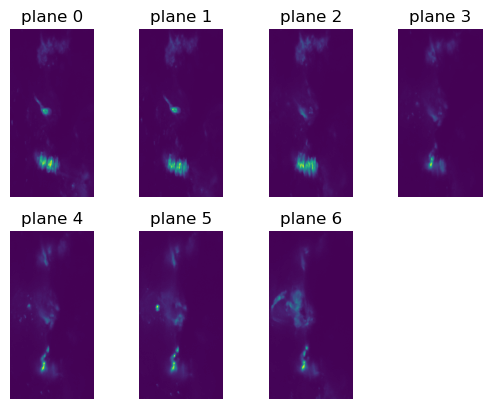

2024-07-29 16:55:14,677 - INFO - gulp2p.preproc.imaging - [imaging.py preprocess() 568] - Motion correction has already been computed, applying shifts
2024-07-29 16:55:46,486 - INFO - gulp2p.preproc.imaging - [imaging.py preprocess() 643] - Saving trial


Truncated fictrac recording. Difference in length: 6
posDf did not contain tortuosity, curvature, voltes or stitched positions
posDf did not contain flight
posDf did not contain clipped


AttributeError: 'PureWindowsPath' object has no attribute 'mkdir'

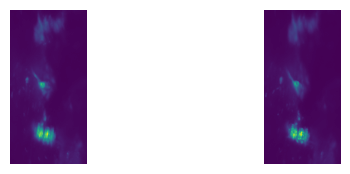

In [4]:
imaging.process_all(tiff_paths, save=True, skip=False, use_full_volume=False)

## Test trial stitching

In [ ]:
# TRIAL_TIFF_PATHS = [Path(r'Z:/2PImaging/Kerstin/MIMS/20240129/20240129_DR19xiGluSnFR_Fly1_00003.tif'),
#                     Path(r'Z:/2PImaging/Kerstin/MIMS/20240129/20240129_DR19xiGluSnFR_Fly1_00005.tif')]

trials = []
for tiff_path in tiff_paths:
    tiff = Tiff(tiff_path)
    trials.append(utils.load_trial(tiff))
expt = Experiment(trials)

In [ ]:
# Find start frames of trials
trial_start_frames = []
for i in range(len(trials)):
    trial_start_frames.append(expt.synced_df.trial.searchsorted(i, side='left'))

In [ ]:
trial_start_frames

[0, 2340, 4929, 7519, 10108, 12699, 15289]

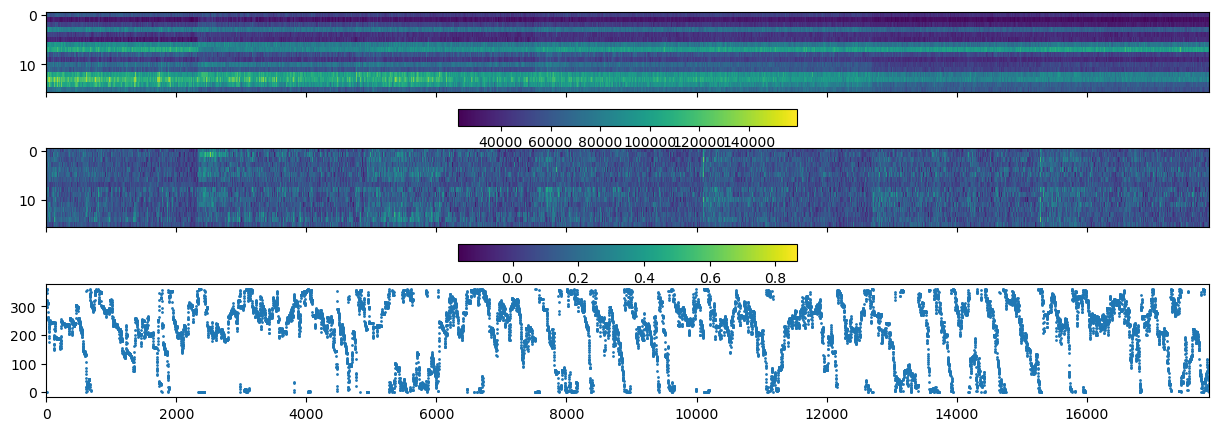

In [ ]:
from matplotlib import cm
from matplotlib.colors import Normalize

num_rois = len(trials[0].rois)

fig, axs = plt.subplots(3, figsize=(15,5), sharex=True)
raw_flor_vmin = None
raw_flor_vmax = None
for index, trial in enumerate(expt.trials):
    trial_vmin = np.min(trial.raw_flor)
    if raw_flor_vmin is None:
        raw_flor_vmin = trial_vmin
    if trial_vmin < raw_flor_vmin:
        raw_flor_vmin = trial_vmin
    trial_vmax = np.max(trial.raw_flor)
    if raw_flor_vmax is None:
        raw_flor_vmax = trial_vmax
    if trial_vmax > raw_flor_vmax:
        raw_flor_vmax = trial_vmax

    start_frame = trial_start_frames[index]
    trial_frame_length = trial.synced_df.shape[0]
    left = start_frame
    right = start_frame + trial_frame_length
    bottom = len(trial.rois)
    top = 0
    extent = (left-0.5, right-0.5, bottom-0.5, top-0.5)
    axs[0].imshow(trial.raw_flor.T,
                  extent=extent,
                  aspect="auto",
                  interpolation="none",
                  vmin = raw_flor_vmin,
                  vmax = raw_flor_vmax)
axs[0].set_xlim([0, start_frame + trial_frame_length])
fig.colorbar(cm.ScalarMappable(norm=Normalize(raw_flor_vmin, raw_flor_vmax), cmap='viridis'),
             ax=axs[0], orientation='horizontal')
deltaf_img = axs[1].imshow(expt.synced_df.iloc[:, :num_rois].T, aspect="auto", interpolation="none")
fig.colorbar(deltaf_img, cmap='viridis', ax=axs[1], orientation='horizontal')
axs[2].scatter(expt.synced_df.index, expt.synced_df['angle'], s=1)

# fig.savefig("20240215_DR018xiGluSnFR_Fly01.png")

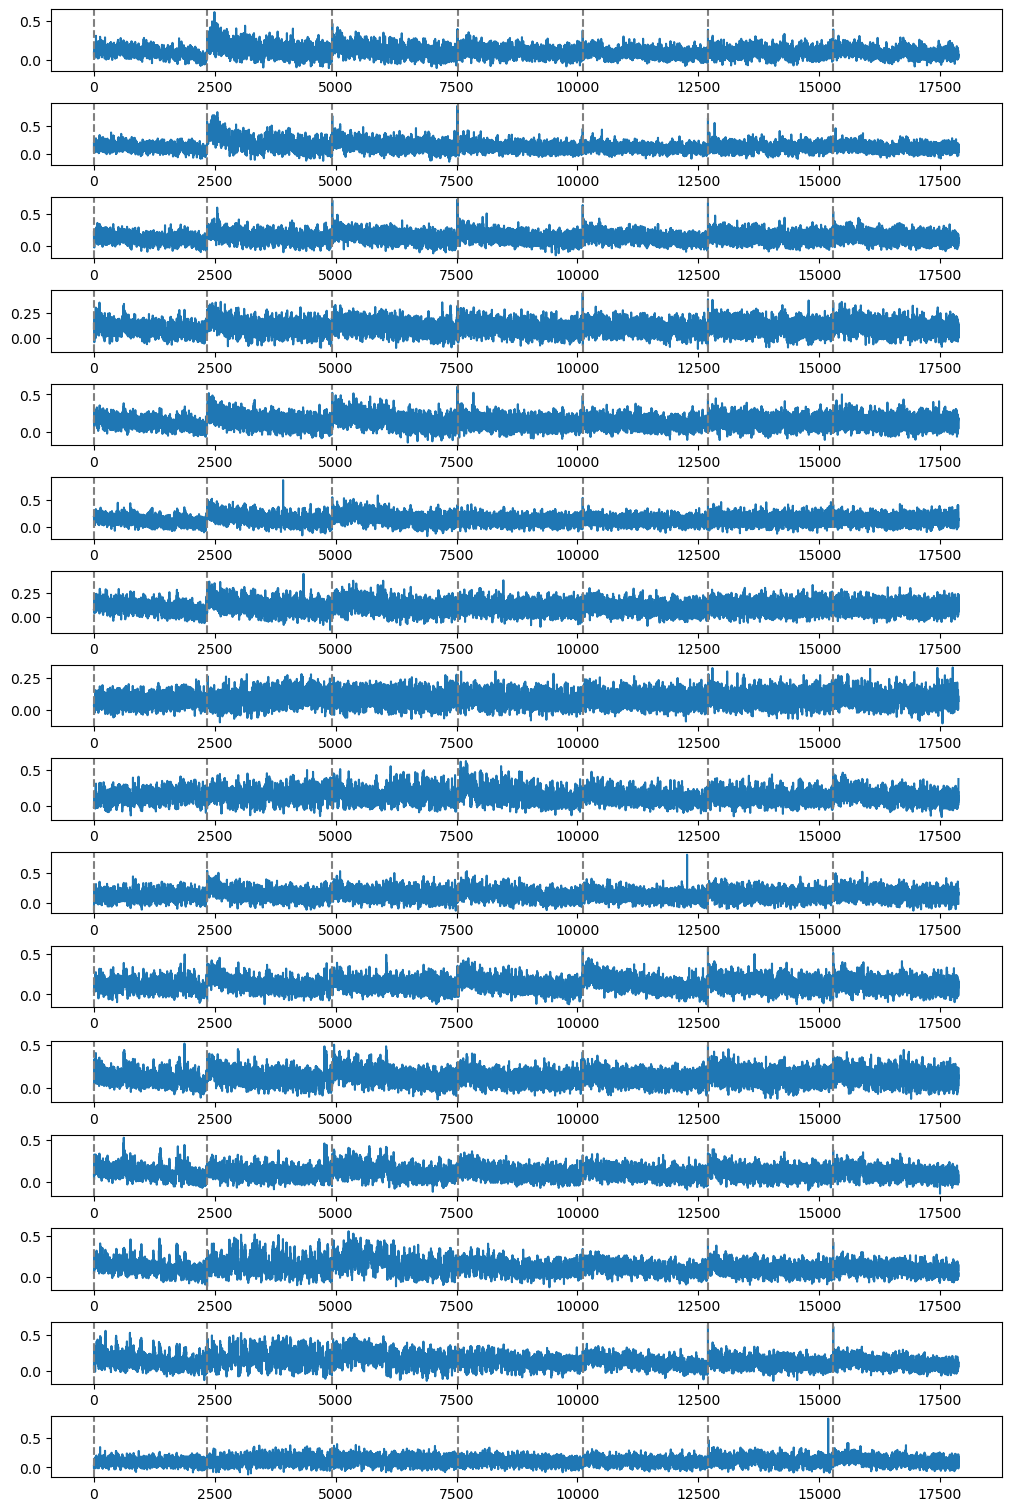

In [ ]:
fig, axs = plt.subplots(nrows=num_rois, figsize=(10, 15), layout="constrained")
for i in range(num_rois):
    axs[i].plot(expt.synced_df.iloc[:, i])
    for frame in trial_start_frames:
        axs[i].axvline(frame, linestyle="--", color="gray")

## Analyze experiment:

Outline:
- Analyze upper and lower pb arm seperately
- Plot heatmap of upper and lower pb
- Plot external head direction
- Plot mean profile of bump
- Fit to cosine
- Quantify the quality of the fit

In [ ]:
trials = []
for tiff_path in tiff_paths:
    tiff = Tiff(tiff_path)
    trials.append(utils.load_trial(tiff))
expt = Experiment(trials)

In [ ]:
# Find start frames of trials
trial_start_frames = []
for i in range(len(trials)):
    trial_start_frames.append(expt.synced_df.trial.searchsorted(i, side='left'))

### Heatmap

#### Functions:

In [ ]:
def plot_heatmap(flor, axes=None, aspect=32, plot_cbar=True):
    if axes is None: 
        fig = plt.figure()
        ax = fig.add_subplot()
    else:
        ax = axes
        fig = axes.get_figure()

    im = ax.imshow(flor.T, aspect=aspect, interpolation='none', norm=CenteredNorm(), cmap='PiYG')
    ax.invert_yaxis()

    if plot_cbar:
        cbar = fig.colorbar(im, ax=ax, shrink=0.5)
        clim = [np.min(flor), np.max(flor)]
        cbar.ax.set_ylim(clim)
        cbar.set_ticks([clim[0], 0, clim[1]])

    if axes is not None:
        return
    else:
        return fig, ax

def plot_rawf_heatmap(expt, ax, with_cbar=True):
    from matplotlib import cm
    from matplotlib.colors import Normalize

    raw_flor_vmin = None
    raw_flor_vmax = None
    for index, trial in enumerate(expt.trials):
        trial_vmin = np.min(trial.raw_flor)
        if raw_flor_vmin is None:
            raw_flor_vmin = trial_vmin
        if trial_vmin < raw_flor_vmin:
            raw_flor_vmin = trial_vmin
        trial_vmax = np.max(trial.raw_flor)
        if raw_flor_vmax is None:
            raw_flor_vmax = trial_vmax
        if trial_vmax > raw_flor_vmax:
            raw_flor_vmax = trial_vmax

        start_frame = trial_start_frames[index]
        trial_frame_length = trial.synced_df.shape[0]
        left = start_frame
        right = start_frame + trial_frame_length
        bottom = len(trial.rois)
        top = 0
        extent = (left-0.5, right-0.5, bottom-0.5, top-0.5)
        ax.imshow(trial.raw_flor.T,
                  extent=extent,
                  aspect="auto",
                  interpolation="none",
                  vmin = raw_flor_vmin,
                  vmax = raw_flor_vmax)
    ax.set_xlim([0, start_frame + trial_frame_length])
    if with_cbar:
        fig.colorbar(cm.ScalarMappable(norm=Normalize(raw_flor_vmin, raw_flor_vmax), cmap='viridis'),
                     ax=ax, orientation='horizontal')

def plot_deltaf_heatmap(expt, ax, mode="upper"):
    # TODO: add dotted lines at border between trials
    if mode == "full":
       ax.imshow(expt.synced_df.iloc[:, :expt.num_rois].T,
                 aspect="auto", interpolation="none")
    if mode == "upper":
       ax.imshow(expt.synced_df.iloc[:, expt.rois_per_arm:expt.num_rois].T,
                 aspect="auto", interpolation="none")
    if mode == "lower":
       ax.imshow(expt.synced_df.iloc[:, 0:expt.rois_per_arm].T,
                 aspect="auto", interpolation="none")


#### Plot:

(0.0, 360.0)

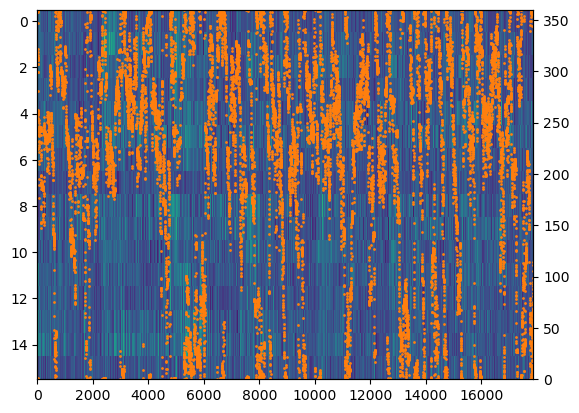

In [ ]:
ax = plt.subplot()
plot_deltaf_heatmap(expt, ax, mode="full")
ax2 = ax.twinx()
ax2.plot(expt.synced_df['angle'], marker='o', linestyle="", ms=1, color="C1")
ax2.set_ylim(0, 360)

### Mean Bump Profile:

#### Functions:

In [ ]:
import pingouin

def get_roi_angles(num_rois):
    """Given the number of rois in one PB arm return a list sequentially assigning each roi to an angle

    Args:
        num_rois (int): number of rois in one PB arm (or in full EB)

    Returns:
        NDArray: Returns a list where at index i it has the angle for ROI i. 
    """
    return np.linspace(0,(2*np.pi),num_rois, endpoint=False)

def angle_roi_to_radians(roi_angle, low=0, high=8):
    return roi_angle/(high-low) * 2*np.pi

def angle_radians_to_roi(rad_angle, num_roi):
    roi_angle = rad_angle/(2*np.pi) * num_roi
    return roi_angle

def get_mean_roi(roi_weights, precise=False):
    num_rois = len(roi_weights)
    angles = get_roi_angles(num_rois)
    circ_mean_rad = pingouin.circ_mean(angles=angles, w=roi_weights)
    if circ_mean_rad < 0:
        circ_mean_rad += 2*np.pi
    roi_angle = angle_radians_to_roi(circ_mean_rad, num_rois)
    if not precise:
        roi_angle = round(roi_angle)
    return roi_angle

def get_mean_rois(deltaf_df, precise=False):
    num_frames, num_rois = deltaf_df.shape
    angles = np.repeat(np.expand_dims(get_roi_angles(num_rois), axis=0), num_frames, axis=0)
    circ_mean_rad = pingouin.circ_mean(angles=angles, w=deltaf_df, axis=1)
    # convert range -pi to pi into 0 to 2pi
    mask = (circ_mean_rad<0)
    circ_mean_rad[mask] += 2*np.pi

    roi_angle = angle_radians_to_roi(circ_mean_rad, num_rois)
    if not precise:
        roi_angle = np.round(roi_angle).astype(np.int32)
        roi_angle = roi_angle % num_rois
    return roi_angle

def get_circ_r(roi_weights):
    num_rois = len(roi_weights)
    angles = get_roi_angles(num_rois)
    return pingouin.circ_r(angles=angles, w=roi_weights)

def get_circ_rs(deltaf_df):
    num_frames, num_rois = deltaf_df.shape
    angles = np.repeat(np.expand_dims(get_roi_angles(num_rois), axis=0), num_frames, axis=0)
    return pingouin.circ_r(angles=angles, w=deltaf_df, axis=1)

def filter_mean_rois(mean_rois, circ_rs, min_r=0.15):
    # in place change
    if np.issubdtype(mean_rois.dtype , np.integer):
        empty_value = -1
    else:
        empty_value = np.nan
    
    mask = (circ_rs <  min_r)
    mean_rois[mask] = empty_value
    return mean_rois

In [ ]:
def align_bumps(deltaf_df, mean_rois=None, min_r = 0, offset=0, shift_peak_flor=False, use_max_as_peak=False):
    aligned_bumps = deltaf_df.copy()

    if mean_rois is None:
        mean_rois = get_mean_rois(aligned_bumps, precise=False)

    if min_r > 0:
        circ_rs = get_circ_rs(aligned_bumps)
        filter_mean_rois(mean_rois, circ_rs)

    for frame, mean_roi in enumerate(mean_rois):

        roll_amount = -1 * mean_roi + offset
        aligned_bump = np.roll(aligned_bumps[frame, :], roll_amount)
        if shift_peak_flor:
            if use_max_as_peak:
                peak_deltaf = np.max(aligned_bump)
            else:
                peak_deltaf = aligned_bump[offset]
            aligned_bump += 1 - peak_deltaf
        aligned_bumps[frame, :] = aligned_bump

        # if frame < 10:
        #     print(mean_roi)
        #     print(peak_deltaf)
        #     print(aligned_bump)

    return aligned_bumps

#### Plot:

Text(0.5, 1.0, 'aligned bumps')

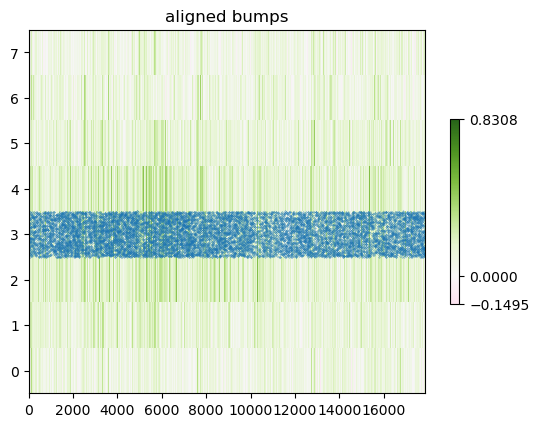

In [ ]:
upper_deltaf = np.array(expt.synced_df.iloc[:, expt.rois_per_arm:expt.num_rois])

aligned_bumps = align_bumps(upper_deltaf, min_r = 0.15, offset=3)
# aligned_bumps = align_bumps(upper_deltaf)

aligned_bumps

fig, ax = plt.subplots()

mean_rois = get_mean_rois(aligned_bumps, precise=True)
circ_rs = get_circ_rs(aligned_bumps)

mask = (circ_rs <  0.15)
mean_rois[mask] = None

ax.plot(mean_rois, lw=0, marker='o', ms=0.25)

plot_heatmap(aligned_bumps, axes=ax, aspect=2**11)

ax.set_title("aligned bumps")

In [ ]:
def plot_bump_profile(aligned_bumps, ax, with_std=True):
    mean_bump = np.mean(aligned_bumps, axis=0)
    std_bump = np.std(aligned_bumps, axis=0)
    ax.plot(mean_bump, color='black')

    if with_std:
        ax.plot(mean_bump + std_bump)
        ax.plot(mean_bump - std_bump)

    ax.set_ylabel("df/f")
    ax.set_xlabel("roi")


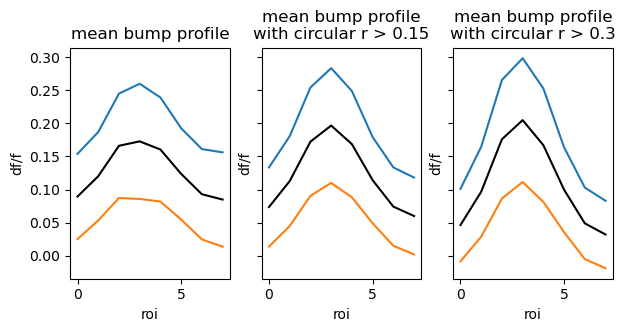

In [ ]:
circ_rs = get_circ_rs(aligned_bumps)
circ_r_mins = [0.15, 0.3]

fig, axs = plt.subplots(1,len(circ_r_mins)+1,
                        figsize=(7,3), sharey=True)
plot_bump_profile(aligned_bumps, axs[0])
axs[0].set_title("mean bump profile")
for index, circ_r_min in enumerate(circ_r_mins):
    filtered_aligned_bumps = aligned_bumps[circ_rs > circ_r_min]
    plot_bump_profile(filtered_aligned_bumps, axs[index+1])
    axs[index+1].set_title(f"mean bump profile\nwith circular r > {circ_r_min}")

### Fit to cosine

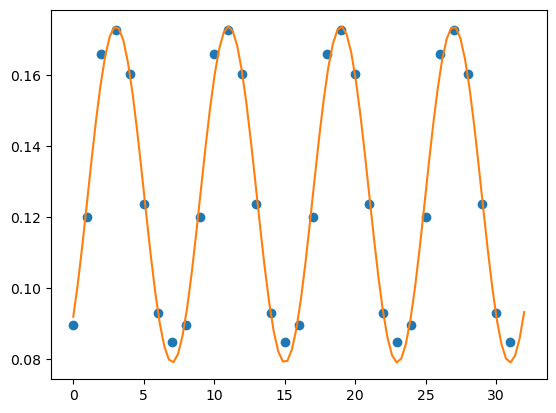

In [ ]:
from scipy.optimize import curve_fit

# https://education.molssi.org/python-data-analysis/03-data-fitting/index.html

def cos_func(x, A, B, C, D):
    y = A*np.cos(B*(x-C)) + D
    return y

repeats = 4
mean_bump = np.mean(aligned_bumps, axis=0)
xdata = range(len(mean_bump)*repeats)
ydata = np.tile(mean_bump, repeats)

initial_params = [1, 2*np.pi/8, 8/2, 0.5]
cont_xdata = np.linspace(0, len(mean_bump)*repeats, 100)
parameters, covariance = curve_fit(cos_func, xdata, ydata,
                                    initial_params,
                                    method='lm')
fit_cosine = cos_func(cont_xdata, *parameters)

plt.plot(xdata, ydata, 'o', label='data')
plt.plot(cont_xdata, fit_cosine, '-', label='fit')

In [ ]:
# R2
residuals = ydata- cos_func(xdata, *parameters)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata-np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.9857480857661384
